# Sistema de prediccion de ventas

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

ModuleNotFoundError: No module named 'pmdarima'

In [30]:
# Cargamos el data set
ruta = r"../data/raw/sales.csv"
df = pd.read_csv(ruta, sep=",")

In [31]:
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [32]:
df.dtypes

date      object
sales    float64
dtype: object

In [33]:
df.describe()

,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


In [34]:
df.isnull().sum()

date     0
sales    0
dtype: int64

## Convertimos la columna date y agrupamos ventas

In [35]:
df['date'] = pd.to_datetime(df['date'])  # Asegurar formato de fecha
ventas_por_fecha = df.groupby('date')['sales'].sum()

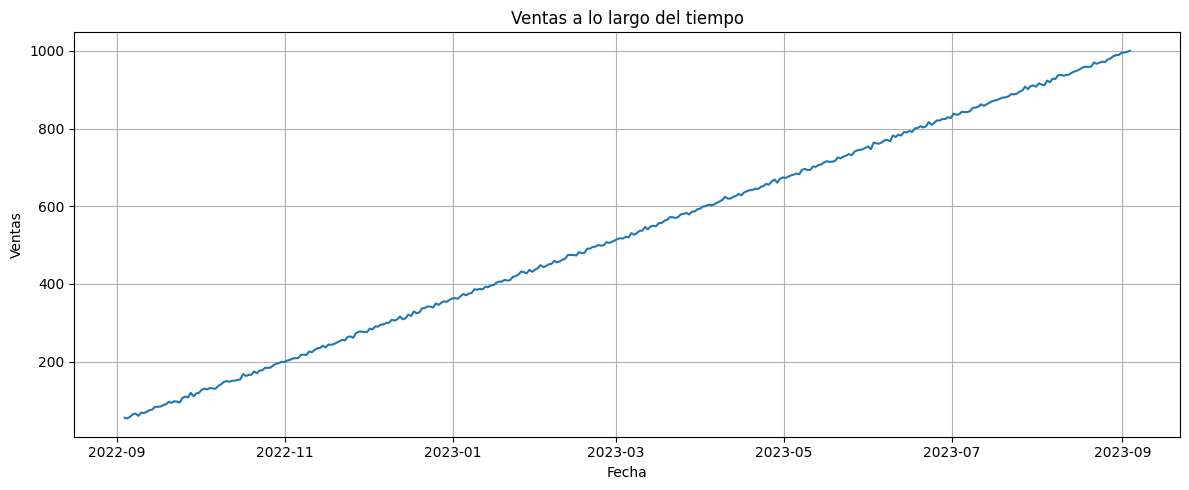

In [36]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=ventas_por_fecha.index, y=ventas_por_fecha.values)
plt.title("Ventas a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

# Descomposicion de la serie temporal

In [ ]:
# Convertir 'date' a datetime y poner como índice
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [ ]:
# Rellenar fechas faltantes con frecuencia diaria
df = df.asfreq('D')

In [ ]:
# Rellenar valores vacíos con interpolación
df['sales'] = df['sales'].interpolate()

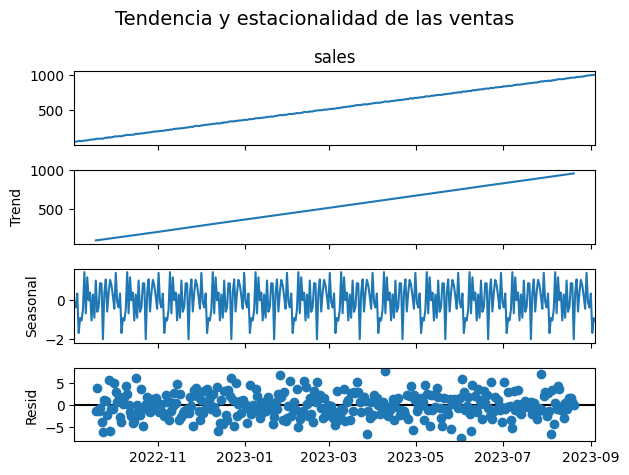

In [37]:
# Descomponer la serie (estacionalidad mensual aprox = 30 días)
result = seasonal_decompose(df['sales'], model='additive', period=30)
result.plot()
plt.suptitle('Tendencia y estacionalidad de las ventas', fontsize=14)
plt.tight_layout()
plt.show()

### Ejercicio `¿Cual es el tensor de la serie temporal?`:
> - Aquí la serie temporal es unidimensional (una sola variable: sales) indexada por fechas (índice temporal). Es decir, la estructura es un vector 1D (serie temporal) con una dimensión temporal.
> - Por lo tanto, podríamos decir que el tensor es de forma (n,), donde n es el número total de días en la serie.

In [38]:
f"la serie tiene {df.shape[0]} datos (dias)."

'la serie tiene 366 datos (dias).'

## Ejercicio `¿Cual es la tendencia?`:
> - Para calcular la tendencia usamos la descomposicion ya vista:

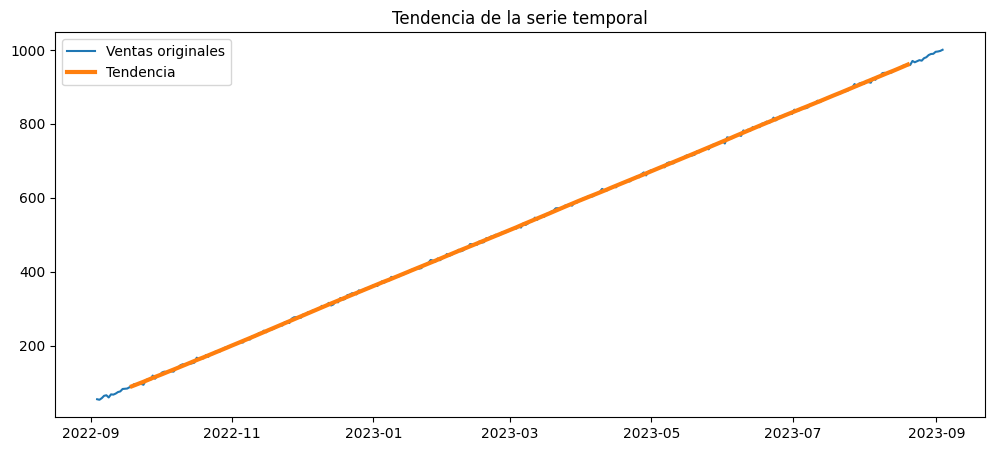

In [39]:
result = seasonal_decompose(df['sales'], model='additive', period=30)

# Graficar tendencia
plt.figure(figsize=(12,5))
plt.plot(df.index, df['sales'], label='Ventas originales')
plt.plot(result.trend, label='Tendencia', linewidth=3)
plt.title('Tendencia de la serie temporal')
plt.legend()
plt.show()

### Ejercicio `¿Es estacionaria?`:
> - Como sabemos si es estacionaria o no?:

In [40]:
adf_result = adfuller(df['sales'].dropna())
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

if adf_result[1] < 0.05:
    print("La serie es estacionaria (rechazamos H0 de raíz unitaria).")
else:
    print("La serie NO es estacionaria (no rechazamos H0).")

ADF Statistic: 0.545414193706381
p-value: 0.9861899815311065
La serie NO es estacionaria (no rechazamos H0).


## Ejercicio `¿Existe variabilidad o presencia de ruido?`:
> - Sí, hay fluctuaciones y un componente residual que indica presencia de ruido.

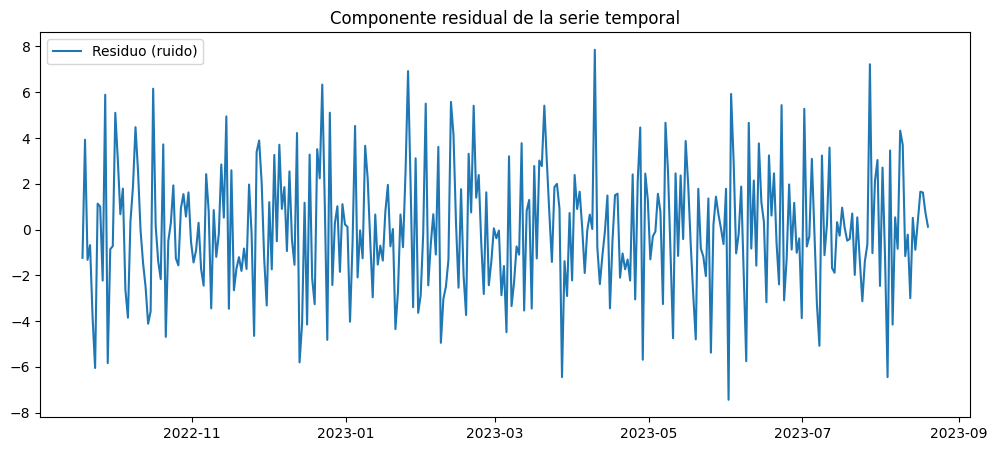

Descripción estadística del residuo:
count    336.000000
mean      -0.007386
std        2.721021
min       -7.438134
25%       -1.725124
50%       -0.177342
75%        1.852219
max        7.852585
Name: resid, dtype: float64


In [41]:
plt.figure(figsize=(12,5))
plt.plot(result.resid, label='Residuo (ruido)')
plt.title('Componente residual de la serie temporal')
plt.legend()
plt.show()

print("Descripción estadística del residuo:")
print(result.resid.describe())

## Separamos los datos en entranamiento y prueba

In [43]:
# Dividir datos (80% entrenamiento, 20% prueba)
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]['sales']
test = df.iloc[train_size:]['sales']

## Buscamos la mejor parametrizacion de ARIMA

In [ ]:
# Encontrar mejor modelo ARIMA automáticamente
modelo_auto = pm.auto_arima(train, seasonal=False, stepwise=True, trace=True,
                           error_action='ignore', suppress_warnings=True,
                           max_p=5, max_q=5, max_d=2)

modelo_auto.summary()

## Entrenamos el moedlo ARIMA con los parametros seleccionado

In [ ]:
# Supongamos que el mejor modelo es ARIMA(p, d, q)
p, d, q = modelo_auto.order

# Entrenar modelo ARIMA con parámetros óptimos
arima_model = ARIMA(train, order=(p,d,q))
arima_result = arima_model.fit()

arima_result.summary()

## Evaluamos desempeño y hacemos predicciones

In [ ]:
# Predecir con el modelo ARIMA usando el conjunto de prueba
preds = arima_result.predict(start=test.index[0], end=test.index[-1], dynamic=False)

# Evaluar rendimiento
mae = mean_absolute_error(test, preds)
rmse = np.sqrt(mean_squared_error(test, preds))

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

# Graficar resultados
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Entrenamiento')
plt.plot(test.index, test, label='Prueba (real)')
plt.plot(preds.index, preds, label='Predicción ARIMA', color='red')
plt.title('Comparación entre valores reales y predicción ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.show()

### Guardamos los archivos

In [50]:
# Guardar datasets
train.to_csv(r'../data/processed/train_sales.csv')
test.to_csv(r'../data/processed/test_sales.csv')

# Guardar modelos
joblib.dump(result, '../models/seasonal_decompose_result.joblib')
joblib.dump(modelo_auto, '../models/auto_arima_model.joblib')
joblib.dump(arima_result, '../models/arima_model.joblib')

NameError: name 'modelo_auto' is not defined